In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('smart_city_complaints_50k.csv')
df['Complaint_Date'] = pd.to_datetime(df['Complaint_Date'])
df['Resolved_Date'] = pd.to_datetime(df['Resolved_Date'], errors='coerce')
print('Rows:', df.shape[0], '| Columns:', df.shape[1])
df.head()

Saving smart_city_complaints_50k.csv to smart_city_complaints_50k (1).csv
Rows: 50000 | Columns: 22


,Complaint_ID,Citizen_Name,Phone_Number,Complaint_Date,Resolved_Date,Zone,Area_Name,Landmark,Category,Department,...,Status,Resolution_Delay_Days,Citizen_Satisfaction_Score,Officer_Assigned,Complaint_Description,Feedback_Comments,Month,Year,Quarter,Week
0,CMP000001,Ravi Rajan,9761337169,2024-10-16,2024-10-20,North-East Zone,Manali,Near Bus Stop,Drainage Problem,Drainage Dept,...,Resolved,4.0,3.2,Officer Ramesh,Drainage pipe broken causing road damage,Team was professional and resolved the issue,October,2024,Q4,42
1,CMP000002,Deepa Annamalai,9569628293,2023-04-25,2023-04-29,Industrial Zone,Thirumudivakkam,Opposite Park,Traffic Congestion,Traffic Management Dept,...,Resolved,4.0,3.3,Officer Meena,Road encroachment by vendors causing traffic i...,Problem fixed but took longer than expected,April,2023,Q2,17
2,CMP000003,Lakshmi Selvan,9907471295,2023-01-26,2023-02-01,North Zone,Kolathur,Opposite Park,Garbage Collection,Sanitation Dept,...,Resolved,6.0,3.8,Officer Ramesh,Garbage collection timing is irregular causing...,Good response from the department,January,2023,Q1,4
3,CMP000004,Kavitha Arumugam,9464320057,2023-10-09,2023-10-21,East Zone,Neelankarai,Opposite School,Traffic Congestion,Traffic Management Dept,...,Resolved,12.0,2.3,Officer Kavitha,Traffic signal not functioning properly,Satisfied with the resolution,October,2023,Q4,41
4,CMP000005,Vijay Murugan,9235045009,2023-09-08,2023-09-17,East Zone,Kottivakkam,Near Bus Stop,Garbage Collection,Sanitation Dept,...,Resolved,9.0,3.4,Officer Usha,Illegal dumping of waste near residential area,Team was professional and resolved the issue,September,2023,Q3,36


In [3]:
df['Resolution_Delay_Days'] = df['Resolution_Delay_Days'].fillna(0)
df['Is_Resolved'] = df['Status'].apply(lambda x: 1 if x == 'Resolved' else 0)
df['Satisfaction_Level'] = pd.cut(df['Citizen_Satisfaction_Score'],
                                   bins=[0,2,3,4,5],
                                   labels=['Dissatisfied','Neutral','Satisfied','Highly Satisfied'])
df.to_csv('smart_city_cleaned.csv', index=False)
print('Cleaned! Shape:', df.shape)

Cleaned! Shape: (50000, 24)


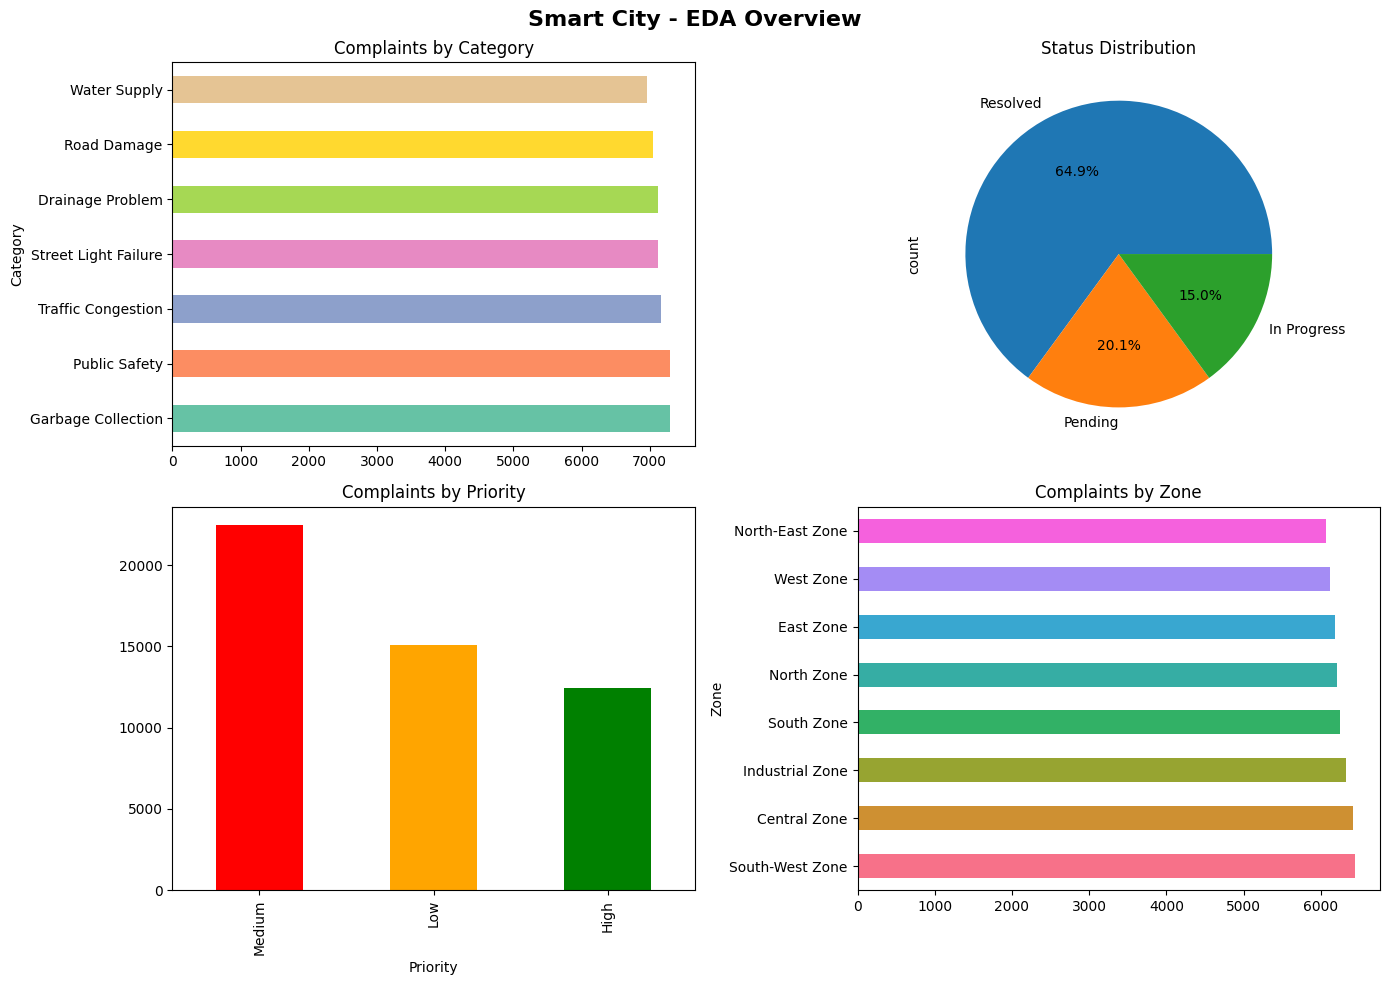

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Smart City - EDA Overview', fontsize=16, fontweight='bold')

df['Category'].value_counts().plot(kind='barh', ax=axes[0,0], color=sns.color_palette('Set2', 7))
axes[0,0].set_title('Complaints by Category')

df['Status'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Status Distribution')

df['Priority'].value_counts().plot(kind='bar', ax=axes[1,0], color=['red','orange','green'])
axes[1,0].set_title('Complaints by Priority')

df['Zone'].value_counts().plot(kind='barh', ax=axes[1,1], color=sns.color_palette('husl', 8))
axes[1,1].set_title('Complaints by Zone')

plt.tight_layout()
plt.savefig('phase1_eda.png', dpi=150)
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('smart_city_cleaned.csv')
print('Rows:', df.shape[0], '| Columns:', df.shape[1])

Rows: 50000 | Columns: 24


In [6]:
total_complaints = len(df)
resolved = df[df['Status'] == 'Resolved'].shape[0]
resolution_rate = (resolved / total_complaints) * 100
avg_resolution = df[df['Resolution_Delay_Days'] > 0]['Resolution_Delay_Days'].mean()
high_priority = df[df['Priority'] == 'High'].shape[0]
avg_satisfaction = df['Citizen_Satisfaction_Score'].mean()

print('Total Complaints    :', total_complaints)
print('Resolved Complaints :', resolved)
print('Resolution Rate     :', round(resolution_rate, 2), '%')
print('Avg Resolution Time :', round(avg_resolution, 2), 'days')
print('High Priority Count :', high_priority)
print('Avg Satisfaction    :', round(avg_satisfaction, 2), '/ 5.0')

Total Complaints    : 50000
Resolved Complaints : 32473
Resolution Rate     : 64.95 %
Avg Resolution Time : 8.11 days
High Priority Count : 12433
Avg Satisfaction    : 2.75 / 5.0


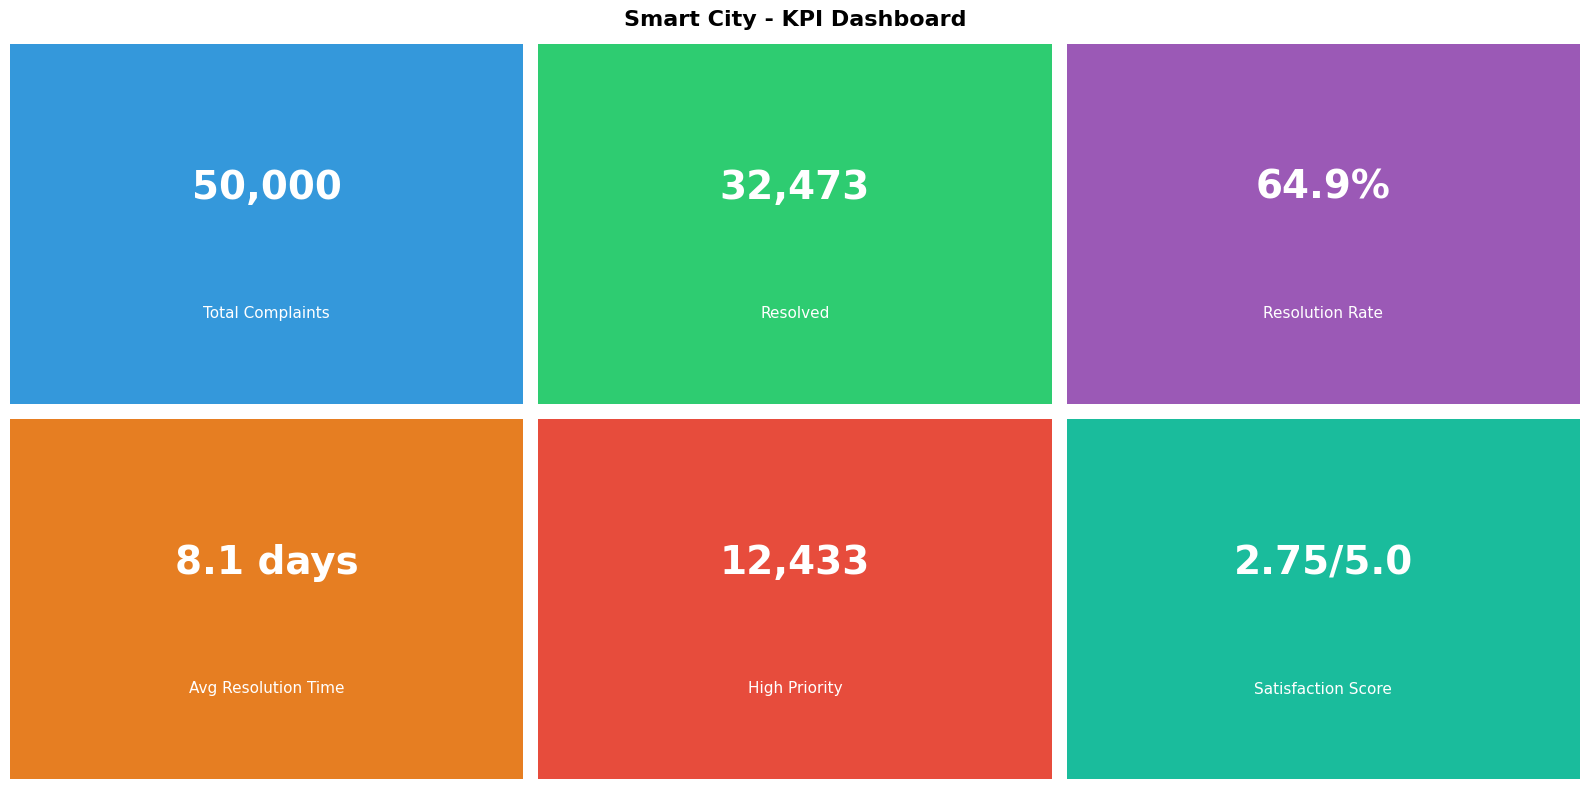

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Smart City - KPI Dashboard', fontsize=16, fontweight='bold')

kpis = [
    ('Total Complaints', f'{total_complaints:,}', '#3498db'),
    ('Resolved', f'{resolved:,}', '#2ecc71'),
    ('Resolution Rate', f'{resolution_rate:.1f}%', '#9b59b6'),
    ('Avg Resolution Time', f'{avg_resolution:.1f} days', '#e67e22'),
    ('High Priority', f'{high_priority:,}', '#e74c3c'),
    ('Satisfaction Score', f'{avg_satisfaction:.2f}/5.0', '#1abc9c'),
]

for idx, (title, value, color) in enumerate(kpis):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=28, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=11, color='white', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig('phase2_kpi.png', dpi=150)
plt.show()

In [8]:
dept = df.groupby('Department').agg(
    Total=('Complaint_ID', 'count'),
    Resolved=('Is_Resolved', 'sum'),
    Avg_Delay=('Resolution_Delay_Days', 'mean'),
    Avg_Satisfaction=('Citizen_Satisfaction_Score', 'mean')
).reset_index()

dept['Resolution_Rate'] = (dept['Resolved'] / dept['Total'] * 100).round(2)
dept['Avg_Delay'] = dept['Avg_Delay'].round(2)
dept['Avg_Satisfaction'] = dept['Avg_Satisfaction'].round(2)

dept[['Department', 'Total', 'Resolution_Rate', 'Avg_Delay', 'Avg_Satisfaction']]

,Department,Total,Resolution_Rate,Avg_Delay,Avg_Satisfaction
0,Drainage Dept,7112,64.51,5.22,2.74
1,Electricity Dept,7126,64.30,5.20,2.73
2,Police Dept,7291,65.85,5.36,2.76
3,Public Works Dept,7050,65.43,5.26,2.75
4,Sanitation Dept,7295,64.84,5.32,2.74
5,Traffic Management Dept,7163,64.58,5.24,2.74
6,Water Supply Dept,6963,65.10,5.28,2.74


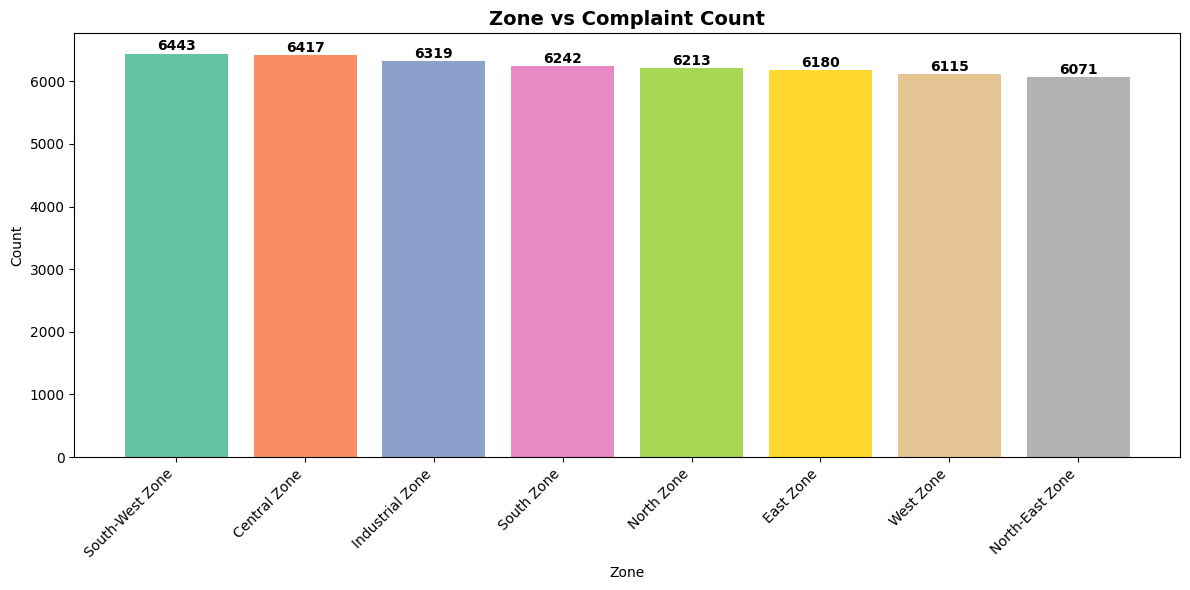

In [9]:
plt.figure(figsize=(12, 6))
zone_counts = df['Zone'].value_counts()
bars = plt.bar(zone_counts.index, zone_counts.values,
               color=sns.color_palette('Set2', len(zone_counts)))
plt.title('Zone vs Complaint Count', fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, zone_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_zone.png', dpi=150)
plt.show()

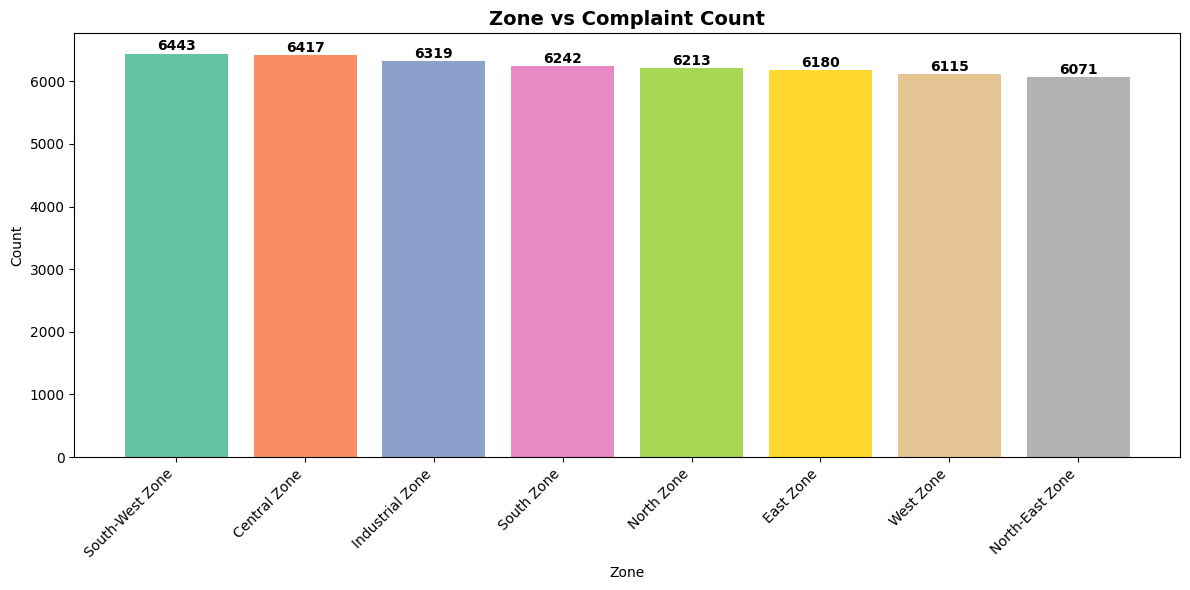

In [10]:
plt.figure(figsize=(12, 6))
zone_counts = df['Zone'].value_counts()
bars = plt.bar(zone_counts.index, zone_counts.values,
               color=sns.color_palette('Set2', len(zone_counts)))
plt.title('Zone vs Complaint Count', fontsize=14, fontweight='bold')
plt.xlabel('Zone')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, zone_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_zone.png', dpi=150)
plt.show()

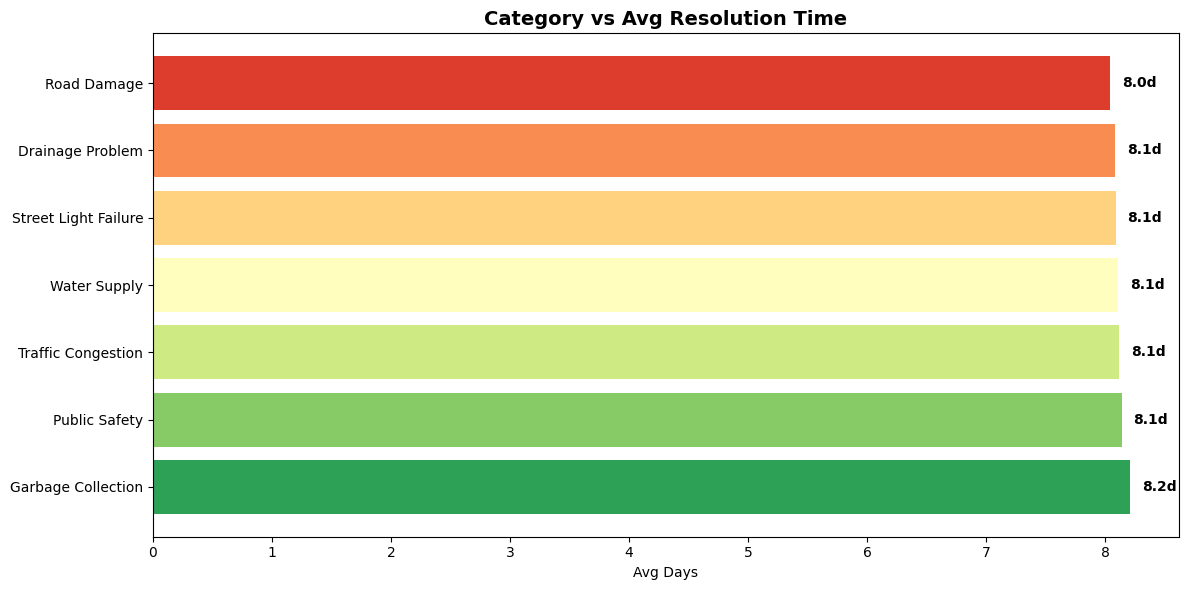

In [11]:
plt.figure(figsize=(12, 6))
cat_res = df[df['Resolution_Delay_Days'] > 0].groupby('Category')['Resolution_Delay_Days'].mean().sort_values(ascending=False)
bars = plt.barh(cat_res.index, cat_res.values,
                color=sns.color_palette('RdYlGn_r', len(cat_res)))
plt.title('Category vs Avg Resolution Time', fontsize=14, fontweight='bold')
plt.xlabel('Avg Days')
for bar, val in zip(bars, cat_res.values):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}d', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_category.png', dpi=150)
plt.show()

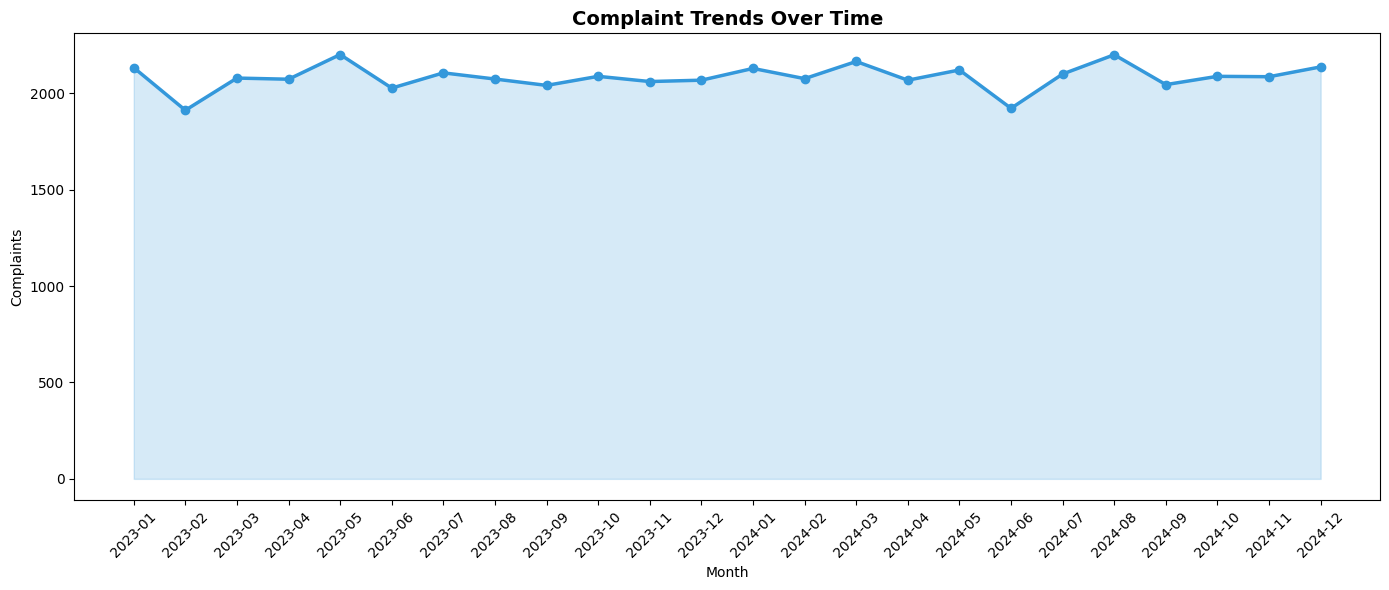

In [12]:
plt.figure(figsize=(14, 6))
df['Complaint_Date'] = pd.to_datetime(df['Complaint_Date']) # Convert to datetime
monthly = df.groupby([df['Complaint_Date'].dt.to_period('M')])['Complaint_ID'].count()
monthly.index = monthly.index.astype(str)
plt.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='#3498db')
plt.fill_between(monthly.index, monthly.values, alpha=0.2, color='#3498db')
plt.title('Complaint Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_trends.png', dpi=150)
plt.show()

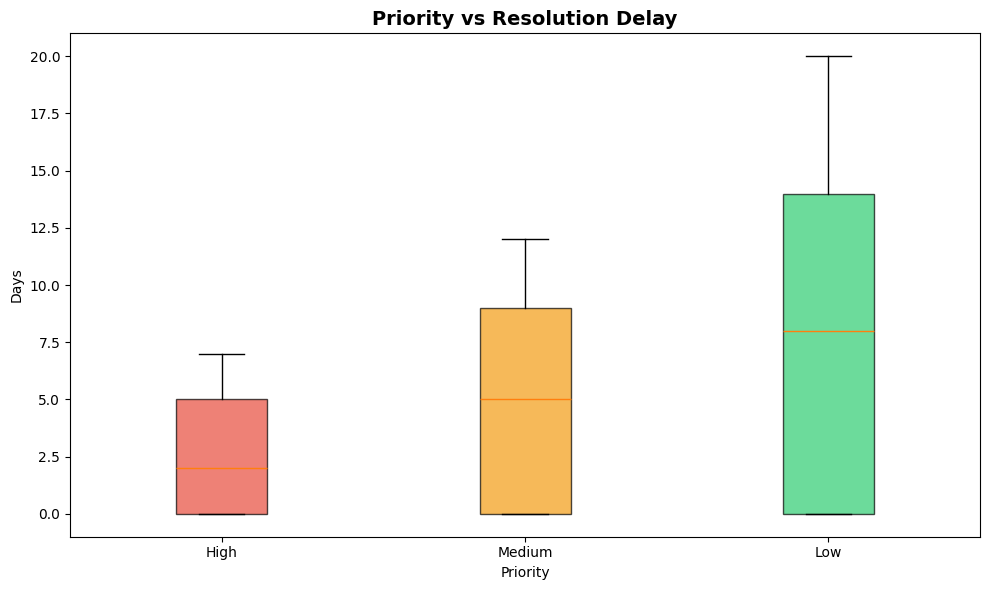

In [13]:
plt.figure(figsize=(10, 6))
priority_order = ['High', 'Medium', 'Low']
colors = ['#e74c3c', '#f39c12', '#2ecc71']
data = [df[df['Priority'] == p]['Resolution_Delay_Days'].dropna() for p in priority_order]
bp = plt.boxplot(data, labels=priority_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.title('Priority vs Resolution Delay', fontsize=14, fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Days')
plt.tight_layout()
plt.savefig('chart4_priority.png', dpi=150)
plt.show()

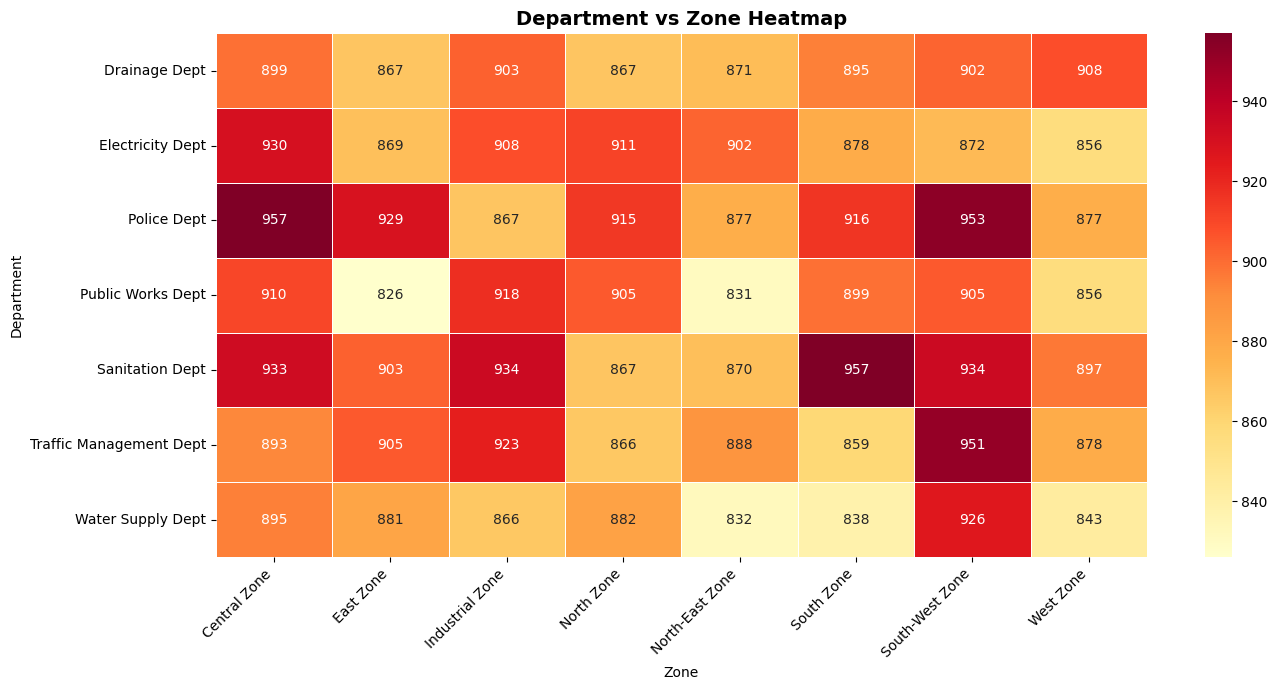

In [14]:
plt.figure(figsize=(14, 7))
dept_zone = df.groupby(['Department', 'Zone'])['Complaint_ID'].count().unstack(fill_value=0)
sns.heatmap(dept_zone, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Department vs Zone Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()

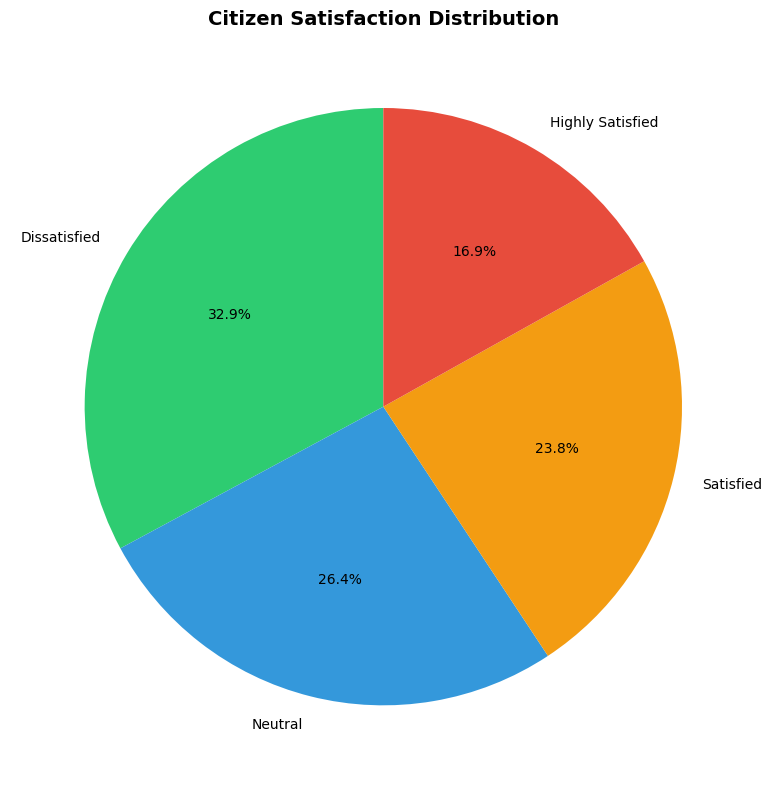

Phase 3 Complete!


In [15]:
plt.figure(figsize=(8, 8))
sat_counts = df['Satisfaction_Level'].value_counts()
plt.pie(sat_counts.values, labels=sat_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
        startangle=90)
plt.title('Citizen Satisfaction Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_satisfaction.png', dpi=150)
plt.show()
print('Phase 3 Complete!')

In [16]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
print('Plotly Ready!')

Plotly Ready!


In [17]:
total = len(df)
resolved = df[df['Status']=='Resolved'].shape[0]
rate = round((resolved/total)*100, 1)
avg_delay = round(df[df['Resolution_Delay_Days']>0]['Resolution_Delay_Days'].mean(), 1)
high_pri = df[df['Priority']=='High'].shape[0]
satisfaction = round(df['Citizen_Satisfaction_Score'].mean(), 2)

fig = go.Figure()
fig.add_trace(go.Indicator(mode='number', value=total, title={'text': 'Total Complaints'}, domain={'x': [0, 0.33], 'y': [0.5, 1]}))
fig.add_trace(go.Indicator(mode='number', value=resolved, title={'text': 'Resolved'}, domain={'x': [0.33, 0.66], 'y': [0.5, 1]}))
fig.add_trace(go.Indicator(mode='number', value=rate, title={'text': 'Resolution Rate %'}, domain={'x': [0.66, 1], 'y': [0.5, 1]}))
fig.add_trace(go.Indicator(mode='number', value=avg_delay, title={'text': 'Avg Days'}, domain={'x': [0, 0.33], 'y': [0, 0.5]}))
fig.add_trace(go.Indicator(mode='number', value=high_pri, title={'text': 'High Priority'}, domain={'x': [0.33, 0.66], 'y': [0, 0.5]}))
fig.add_trace(go.Indicator(mode='number', value=satisfaction, title={'text': 'Satisfaction /5.0'}, domain={'x': [0.66, 1], 'y': [0, 0.5]}))
fig.update_layout(title='Smart City KPI Dashboard', height=500)
fig.show()

In [18]:
cat_counts = df['Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']

fig = px.bar(cat_counts, x='Count', y='Category', orientation='h',
             title='Complaints by Category',
             color='Count', color_continuous_scale='Blues', text='Count')
fig.update_traces(textposition='outside')
fig.update_layout(height=450)
fig.show()

In [19]:
monthly = df.groupby(df['Complaint_Date'].dt.to_period('M'))['Complaint_ID'].count().reset_index()
monthly['Complaint_Date'] = monthly['Complaint_Date'].astype(str)

fig = px.line(monthly, x='Complaint_Date', y='Complaint_ID',
              title='Complaint Trends Over Time',
              markers=True, color_discrete_sequence=['#3498db'])
fig.update_traces(fill='tozeroy', fillcolor='rgba(52,152,219,0.2)')
fig.update_layout(height=400, xaxis_title='Month', yaxis_title='Complaints')
fig.show()

In [20]:
zone_counts = df['Zone'].value_counts().reset_index()
zone_counts.columns = ['Zone', 'Count']

fig = px.pie(zone_counts, names='Zone', values='Count',
             title='Complaints by Zone',
             color_discrete_sequence=px.colors.qualitative.Set2, hole=0.4)
fig.update_layout(height=450)
fig.show()

In [21]:
dept = df.groupby('Department').agg(
    Resolution_Rate=('Is_Resolved', 'mean')).reset_index()
dept['Resolution_Rate'] = (dept['Resolution_Rate'] * 100).round(2)

fig = px.bar(dept, x='Department', y='Resolution_Rate',
             title='Department Resolution Rate (%)',
             color='Resolution_Rate', color_continuous_scale='RdYlGn', text='Resolution_Rate')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=450, xaxis_tickangle=45)
fig.show()
print('Phase 4 Complete!')

Phase 4 Complete!
